In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick
import numpy as np

ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [23]:
bvals = np.linspace(10, 2000, 200)
bvecs = jax.random.normal(jax.random.PRNGKey(0), shape=(200, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.jit
def simulator(rng):
    rng1, rng2 = jax.random.split(rng)
    theta = jax.random.normal(rng1, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(3,))
    model_mask = jnp.array([True, True, True])
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    return model_mask, theta, x_o
    

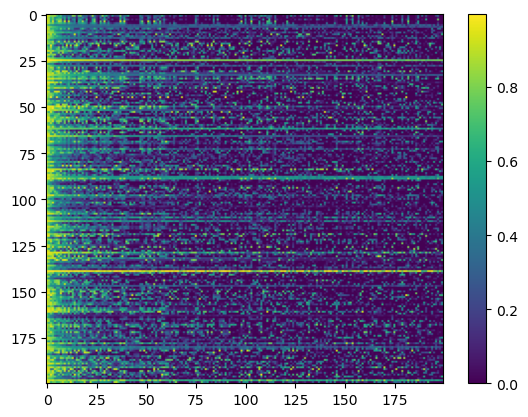

In [24]:
_, theta, x_o = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [25]:
from dmri.nn.tokenizer import StructuredTokenizer
from dmri.nn.autoregressive import ModelIdentificationDecoder
from dmri.nn.simformer import Simformer, MLP, EDM
from flax import nnx


dims_per_component = list(ball_stick.split_idx())
node_ids = [0,1,2,3]
tokenizer = StructuredTokenizer(dims_per_component, rngs=nnx.Rngs(0))
embed_net = MLP([200, 200, 100, 64], rngs=nnx.Rngs(0))
simformer = EDM(Simformer(tokenizer, rngs=nnx.Rngs(0), context_embed=embed_net))

params = nnx.state(simformer, nnx.Param)

In [26]:
simformer(jnp.ones((200,1)), theta, node_ids, context=x_o, condition_mask=None)

Array([[ 1.556,  0.011,  0.05 , ...,  0.335,  1.339, -0.542],
       [-0.299,  0.159, -0.517, ...,  0.441,  1.513, -1.166],
       [ 0.198,  0.076, -0.142, ..., -0.271, -1.571,  0.536],
       ...,
       [ 0.93 ,  0.195, -0.077, ...,  0.678,  1.117, -0.643],
       [ 0.92 , -0.068, -0.777, ..., -0.747, -0.966, -0.372],
       [-0.087,  0.207, -0.726, ..., -0.946,  0.353,  0.071]],      dtype=float32)

In [27]:
import optax 


optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adam(5e-4))


@jax.jit
def loss_fn(params, data, rng):
    components, thetas, xs = data

    loss = simformer.loss(params, rng=rng, data=thetas, node_ids=node_ids, condition_mask=None,context=xs)

    return loss

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss


In [28]:
batch_simulator = jax.jit(jax.vmap(simulator))
opt_state = optimizer.init(params)

In [46]:
key = jax.random.PRNGKey(0)
for i in range(50):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os = batch_simulator(jax.random.split(subkey1, 2**15))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (512,), 0, 2**15)
        masks_batch, thetas_batch, x_os_batch = masks[idx], thetas[idx], x_os[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch), subkey2)
        l += loss
    print(l/500) 

5.212256
5.178584
5.1024075
5.0536804
4.998874
4.95534
4.9087586
4.884907


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcf63695d90>>
Traceback (most recent call last):
  File "/root/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


4.816333
4.777497
4.7414947
4.7187214
4.680659
4.647682
4.623534
4.5849867
4.534348
4.5134788
4.478377
4.4235725
4.41883
4.38005
4.356781
4.327038
4.302831
4.2736974
4.2563863
4.2357974
4.2033086
4.1992126
4.1691704
4.117499
4.1030407
4.07038
4.0716224
4.025995
4.0187664
4.003677
3.977439
3.958144
3.9479256
3.913975
3.9173045
3.892079
3.8881702
3.8591392
3.8473225
3.8208885
3.811844
3.814689


In [47]:
nnx.update(simformer, params)

In [65]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    model = simformer
    eps = jax.random.normal(rng, ball_stick.theta_dim) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


from probjax.utils.sdeint import sdeint

def sample(rng, context):
    model = simformer
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (ball_stick.theta_dim,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    


In [66]:
thetas_post = jax.vmap(sample, in_axes=(0, None))(jax.random.split(jax.random.key(0), 1000), x_os[0])

In [54]:
np.array(thetas[0])

array([-1.843, -0.75 , -1.277,  0.005,  1.298,  0.909,  1.481,  0.471,
        0.074], dtype=float32)

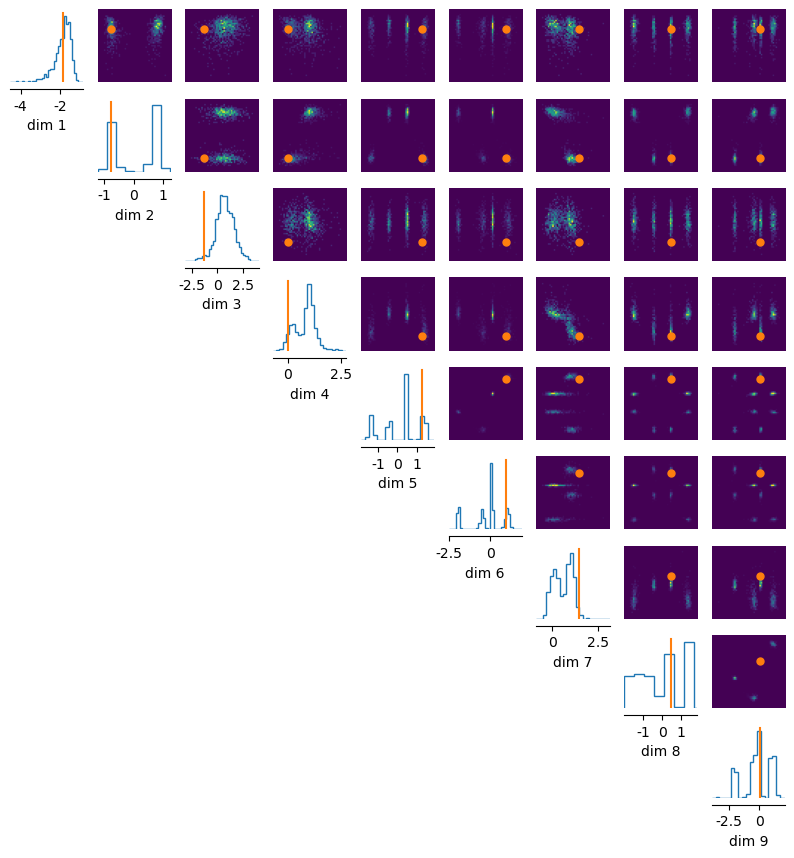

In [67]:
import sbi.analysis.plot 
from sbi.analysis.plot import pairplot
import numpy as np


_ = pairplot(thetas_post, points=thetas[:1])

In [69]:
def posterior_pred(theta):
    return Ball2Stick.from_theta(theta).signal(bvals, bvecs)

posterior_preds = jax.vmap(posterior_pred)(thetas_post)

In [71]:
posterior_preds.shape

(1000, 200)

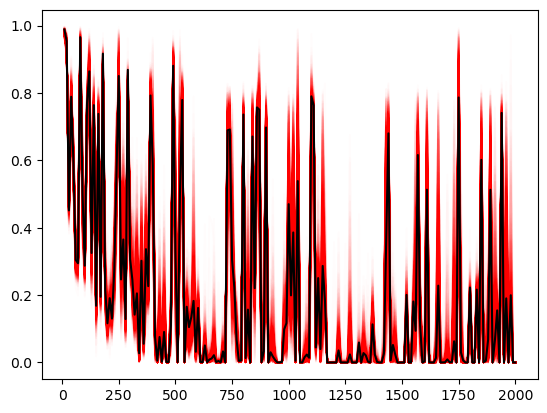

In [ ]:
_ = plt.plot(bvals, posterior_preds.T, label="posterior pred", color="red", alpha=0.01)
_ = plt.plot(bvals, x_os[0], label="data", color="black")